Here are functions (need to be run first):

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
import numpy as np
from google.colab import drive
import matplotlib.pyplot as plt
drive.mount('/content/gdrive')

# SE Block for attention mechanism
class SEBlock(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(SEBlock, self).__init__()
        self.fc1 = nn.Conv2d(in_channels, in_channels // reduction, kernel_size=1)
        self.fc2 = nn.Conv2d(in_channels // reduction, in_channels, kernel_size=1)

    def forward(self, x):
        scale = torch.mean(x, dim=(2, 3), keepdim=True)
        scale = torch.relu(self.fc1(scale))
        scale = torch.sigmoid(self.fc2(scale))
        return x * scale

# Reusable block: Conv3x3 -> BN -> ReLU -> SE
class ConvBNReLUSE(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.bn   = nn.BatchNorm2d(out_ch)
        self.se   = SEBlock(out_ch)
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = F.relu(x, inplace=True)
        x = self.se(x)
        return x

# ------------------------ FCN4: base  -------------------------
class FCN4_ED(nn.Module):
    """Total convs = 4 (3x3: conv1, conv2, conv3; plus final 1x1)."""
    def __init__(self, dropout_p=0.5, align_corners=False):
        super().__init__()
        self.conv1 = ConvBNReLUSE(3, 32)        # /1
        self.conv2 = ConvBNReLUSE(32, 64)       # /2 after pool
        self.conv3 = ConvBNReLUSE(64, 32)       # /2->/1 after upsample
        self.conv4 = nn.Conv2d(32, 1, 1)        # logits (1x1)

        self.pool     = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=align_corners)
        self.dropout  = nn.Dropout(dropout_p)

    def forward(self, x):
        x = self.conv1(x)        # /1
        x = self.pool(x)         # /2
        x = self.conv2(x)        # /2
        x = self.pool(x)         # /4

        x = self.upsample(x)     # /2
        x = self.conv3(x)        # /2
        x = self.upsample(x)     # /1
        x = self.dropout(x)
        x = self.conv4(x)        # logits
        return x

# ---------------- FCN6: add 2 extra 3x3 convs -----------------
class FCN6_ED(nn.Module):
    """Total convs = 6 (adds: one extra 64ch at /4, one extra 32ch at /1)."""
    def __init__(self, dropout_p=0.5, align_corners=False):
        super().__init__()
        self.conv1 = ConvBNReLUSE(3, 32)         # /1
        self.conv2 = ConvBNReLUSE(32, 64)        # /2
        self.mid64 = ConvBNReLUSE(64, 64)        # EXTRA @ /4 (depth +1)
        self.dec32a = ConvBNReLUSE(64, 32)       # /2 -> /1
        self.dec32b = ConvBNReLUSE(32, 32)       # EXTRA @ /1 (depth +1)
        self.conv_out = nn.Conv2d(32, 1, 1)      # logits

        self.pool     = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=align_corners)
        self.dropout  = nn.Dropout(dropout_p)

    def forward(self, x):
        x = self.conv1(x)         # /1
        x = self.pool(x)          # /2
        x = self.conv2(x)         # /2
        x = self.pool(x)          # /4

        x = self.mid64(x)         # EXTRA at /4 (64ch)

        x = self.upsample(x)      # /2
        x = self.dec32a(x)        # to 32ch at /2
        x = self.upsample(x)      # /1
        x = self.dec32b(x)        # EXTRA at /1 (32ch)
        x = self.dropout(x)
        x = self.conv_out(x)
        return x

# ---------------- FCN8: add 4 extra 3x3 convs -----------------
class FCN8_ED(nn.Module):
    """Total convs = 8 (adds: two extra 64ch at /4, two extra 32ch at /1)."""
    def __init__(self, dropout_p=0.5, align_corners=False):
        super().__init__()
        self.conv1 = ConvBNReLUSE(3, 32)          # /1
        self.conv2 = ConvBNReLUSE(32, 64)         # /2
        self.mid64a = ConvBNReLUSE(64, 64)        # EXTRA @ /4
        self.mid64b = ConvBNReLUSE(64, 64)        # EXTRA @ /4
        self.dec32a = ConvBNReLUSE(64, 32)        # /2 -> /1
        self.dec32b = ConvBNReLUSE(32, 32)        # EXTRA @ /1
        self.dec32c = ConvBNReLUSE(32, 32)        # EXTRA @ /1
        self.conv_out = nn.Conv2d(32, 1, 1)

        self.pool     = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=align_corners)
        self.dropout  = nn.Dropout(dropout_p)

    def forward(self, x):
        x = self.conv1(x)          # /1
        x = self.pool(x)           # /2
        x = self.conv2(x)          # /2
        x = self.pool(x)           # /4

        x = self.mid64a(x)         # EXTRA /4
        x = self.mid64b(x)         # EXTRA /4

        x = self.upsample(x)       # /2
        x = self.dec32a(x)         # 64->32
        x = self.upsample(x)       # /1
        x = self.dec32b(x)         # EXTRA /1
        x = self.dec32c(x)         # EXTRA /1
        x = self.dropout(x)
        x = self.conv_out(x)
        return x

# ---------------- FCN10: add 6 extra 3x3 convs -----------------
class FCN10_ED(nn.Module):
    """Total convs = 10 (adds: three extra 64ch at /4, three extra 32ch at /1)."""
    def __init__(self, dropout_p=0.5, align_corners=False):
        super().__init__()
        self.conv1 = ConvBNReLUSE(3, 32)           # /1
        self.conv2 = ConvBNReLUSE(32, 64)          # /2
        self.mid64a = ConvBNReLUSE(64, 64)         # EXTRA @ /4
        self.mid64b = ConvBNReLUSE(64, 64)         # EXTRA @ /4
        self.mid64c = ConvBNReLUSE(64, 64)         # EXTRA @ /4
        self.dec32a = ConvBNReLUSE(64, 32)         # /2 -> /1
        self.dec32b = ConvBNReLUSE(32, 32)         # EXTRA @ /1
        self.dec32c = ConvBNReLUSE(32, 32)         # EXTRA @ /1
        self.dec32d = ConvBNReLUSE(32, 32)         # EXTRA @ /1
        self.conv_out = nn.Conv2d(32, 1, 1)

        self.pool     = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=align_corners)
        self.dropout  = nn.Dropout(dropout_p)

    def forward(self, x):
        x = self.conv1(x)           # /1
        x = self.pool(x)            # /2
        x = self.conv2(x)           # /2
        x = self.pool(x)            # /4

        x = self.mid64a(x)          # EXTRA /4
        x = self.mid64b(x)          # EXTRA /4
        x = self.mid64c(x)          # EXTRA /4

        x = self.upsample(x)        # /2
        x = self.dec32a(x)          # 64->32
        x = self.upsample(x)        # /1
        x = self.dec32b(x)          # EXTRA /1
        x = self.dec32c(x)          # EXTRA /1
        x = self.dec32d(x)          # EXTRA /1
        x = self.dropout(x)
        x = self.conv_out(x)
        return x

# Implementing "early stopping"
class EarlyStopping:
    def __init__(self, patience=8, min_delta=1e-3, mode="min", ckpt_path="best.pt"):
        assert mode in ("min", "max")
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.ckpt_path = ckpt_path
        self.best = None
        self.bad_epochs = 0

    def _is_better(self, current, best):
        if self.mode == "min":
            return current < (best - self.min_delta)
        else:
            return current > (best + self.min_delta)

    def step(self, current_value, model):
        if self.best is None or self._is_better(current_value, self.best):
            self.best = current_value
            self.bad_epochs = 0
            torch.save(model.state_dict(), self.ckpt_path)
            return False  # don't stop
        self.bad_epochs += 1
        return self.bad_epochs >= self.patience  # True => stop


# Function for manual data augmentation
def augment_data(x, y):
    # x: [C,H,W], y: [H,W]
    if random.random() > 0.5:  # horizontal (width axis)
        x = torch.flip(x, [2])
        y = torch.flip(y, [1])
    if random.random() > 0.5:  # vertical (height axis)
        x = torch.flip(x, [1])
        y = torch.flip(y, [0])
    if random.random() > 0.5:
        ang = random.randint(-10, 10)
        x = rotate_tensor_img(x, ang)      # bilinear
        y = rotate_tensor_mask(y, ang)     # nearest
    return x, y

def rotate_tensor_img(x, angle_deg):
    angle = np.deg2rad(angle_deg)
    theta = torch.tensor([[np.cos(angle), -np.sin(angle), 0],
                          [np.sin(angle),  np.cos(angle), 0]], dtype=torch.float, device=x.device).unsqueeze(0)
    N,C,H,W = 1, x.shape[0], x.shape[1], x.shape[2]
    grid = nn.functional.affine_grid(theta, size=(N,C,H,W), align_corners=False)
    return nn.functional.grid_sample(x.unsqueeze(0), grid, mode='bilinear',
                                     padding_mode='zeros', align_corners=False).squeeze(0)

def rotate_tensor_mask(y, angle_deg):
    angle = np.deg2rad(angle_deg)
    theta = torch.tensor([[np.cos(angle), -np.sin(angle), 0],
                          [np.sin(angle),  np.cos(angle), 0]], dtype=torch.float, device=y.device).unsqueeze(0)
    N,C,H,W = 1, 1, y.shape[0], y.shape[1]
    grid = nn.functional.affine_grid(theta, size=(N,C,H,W), align_corners=False)
    return nn.functional.grid_sample(y.unsqueeze(0).unsqueeze(0), grid, mode='nearest',
                                     padding_mode='zeros', align_corners=False).squeeze(0).squeeze(0)


# Combined BCEWithLogitsLoss and Dice Loss
def combined_loss(pred, target, smooth=1.0):
    # pred: [B,1,H,W]
    # target: [B,1,H,W] or [B,H,W]
    if target.dim() == 3:
        target = target.unsqueeze(1)          # -> [B,1,H,W]
    elif target.dim() == 2:
        target = target.unsqueeze(0).unsqueeze(0)  # handle single image path

    target = target.to(pred.dtype)

    # BCE
    bce = F.binary_cross_entropy_with_logits(pred, target)

    # Dice
    probs = torch.sigmoid(pred)
    intersection = (probs * target).sum(dim=(1,2,3))
    denom = probs.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    dice = 1 - ((2.0 * intersection + smooth) / (denom + smooth)).mean()

    return bce + dice

# Function to set the default output probability equals the empirical positive rate
# compute the empirical positive rate
def compute_positive_prior(Y_train):
    """
    Y_train: torch.Tensor of masks, shape [N, 1, H, W] or [N, H, W], values in {0,1}
    returns float p in (0,1)
    """
    with torch.no_grad():
        y = Y_train
        if y.dim() == 3:  # [N,H,W] -> [N,1,H,W]
            y = y.unsqueeze(1)
        p = y.float().mean().item()
        # clamp to avoid inf logits
        p = max(min(p, 1 - 1e-6), 1e-6)
    return p

# set the default probability
def bias_init_final_logits_to_prior(model, p):
    """
    Find the last Conv2d with out_channels==1 and set:
      bias = log(p/(1-p))
      weight = 0
    """
    prior_logit = math.log(p / (1.0 - p))
    last = None
    for m in model.modules():
        if isinstance(m, nn.Conv2d) and m.out_channels == 1:
            last = m
    if last is None:
        raise RuntimeError("No final Conv2d(out_channels=1) found.")
    with torch.no_grad():
        if last.bias is None:
            last.bias = nn.Parameter(torch.empty(1, device=next(model.parameters()).device))
        last.bias.fill_(prior_logit)
        last.weight.zero_()  # optional but helps start “flat”

# Function to train the model with early stopping
def train_model_with_early_stopping(
    model, criterion, optimizer, scheduler,
    X_train, Y_train, X_val, Y_val, device,
    epochs=100, patience=8, min_delta=1e-3, ckpt_path="best_fcn.pt"
):
    early = EarlyStopping(patience=patience, min_delta=min_delta, mode="min", ckpt_path=ckpt_path)

    model.train()
    Ntrain = X_train.size(0)

    for epoch in range(1, epochs+1):
        running_loss = 0.0

        # ---- training (sample-by-sample) ----
        for i in range(Ntrain):
            # x: [1,3,H,W]; y: [1,1,H,W] Squeeze batch dim to use the augment function
            x = X_train[i]      # [3,H,W]
            y = Y_train[i,0]    # [H,W]  Take channel 0 so the augment_data works as written

            # apply augmentation (function expects [C,H,W] and [H,W])
            xa, ya = augment_data(x, y)

            # restore shapes for model: [1,3,H,W] and [1,1,H,W]
            xb = xa.unsqueeze(0).to(device).float()
            yb = ya.unsqueeze(0).unsqueeze(0).to(device).float()

            optimizer.zero_grad()
            outputs = model(norm(xb))                 # [1,1,H,W] expected
            loss = criterion(outputs, yb)       # combined loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item()

        # step the scheduler
        scheduler.step()

        # ---- validation pass (no aug) ----
        model.eval()
        with torch.no_grad():
            val_loss = 0.0
            Nval = X_val.size(0)
            for j in range(Nval):
                xv = X_val[j].unsqueeze(0).to(device).float()     # [1,3,H,W]
                yv = Y_val[j].to(device).float()                  # [1,1,H,W]
                outv = model(norm(xv))
                vloss = criterion(outv, yv)
                val_loss += vloss.item()
            val_loss /= max(1, Nval)
        model.train()

        print(f"Epoch {epoch:03d} | train_loss={running_loss / Ntrain:.4f}  val_loss={val_loss:.4f}")

        # ---- early stopping on validation loss (minimization) ----
        if early.step(val_loss, model):
            print(f"Early stopping at epoch {epoch}. Best val_loss={early.best:.4f}")
            break

    # restore best weights
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()
    return model

# New function to evaluate the model
@torch.no_grad()
def dice_from_logits_binary(logits, target, eps=1e-6):
    # logits: [1,1,H,W], target: [1,1,H,W]
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()
    inter = (preds * target).sum()
    union = preds.sum() + target.sum()
    return ((2*inter + eps) / (union + eps)).item()

@torch.no_grad()
def evaluate_one(model, criterion, x, y, device):
    """
    x: [1,3,H,W] (batched 1)
    y: [H,W] or [1,1,H,W]
    Returns: loss(float), logits [1,1,H,W], dice(float)
    """
    model.eval()
    xb = x.to(device).float()
    if y.ndim == 2:            # [H,W] -> [1,1,H,W]
        yb = y.unsqueeze(0).unsqueeze(0).to(device).float()
    elif y.ndim == 3:          # [1,H,W] -> [1,1,H,W]
        yb = y.unsqueeze(0).to(device).float()
    else:                      # already [1,1,H,W]
        yb = y.to(device).float()

    logits = logits = model(norm(xb))         # [1,1,H,W]
    loss = criterion(logits, yb).item()
    dice = dice_from_logits_binary(logits, yb)
    return loss, logits, dice


# Function to evaluate the model
def evaluate_model(model, criterion, X_eval, y_eval, device):
    model.eval()  # Set the model to evaluation mode
    total_loss = 0.0
    with torch.no_grad():
        for x, y in zip(X_eval, y_eval):
            x = x.to(device).float()
            y = y.to(device).float()

            outputs = model(x.unsqueeze(0))
            outputs = outputs.squeeze() # To match the dimension
            loss = criterion(outputs, y)
            total_loss += loss.item()

    average_loss = total_loss / len(X_eval)
    return average_loss, outputs

# Post-processing function
def post_process(outputs, threshold=0.5):
    outputs = torch.sigmoid(outputs)
    outputs = (outputs > threshold).float()
    return outputs

# Function to create a predicted SZ
def plot_results(y_matrix, title):
    plt.figure(figsize=(8, 2))
    plt.imshow(y_matrix, vmin=0, cmap='binary')
    plt.title(title)
    #plt.colorbar(label='Boolean Value')
    plt.tight_layout()
    plt.show()

# Function to create the original RGB image
def plot_rgb(loaded_tensor_rgb, title):
    np_array = loaded_tensor_rgb.cpu().numpy()
    np_array = np_array / 255.0  # normalize to 0–1
    plt.figure(figsize=(8, 2))
    plt.title(title)
    plt.imshow(np_array)
    plt.tight_layout()
    plt.show()

# Function to create a predicted SZ
def plot_actual(y_matrix, title):
    y_matrix = y_matrix.squeeze(0)
    plt.figure(figsize=(8, 2))
    plt.imshow(y_matrix, vmin=0, cmap='binary')
    plt.title(title)
    #plt.colorbar(label='Boolean Value')
    plt.tight_layout()
    plt.show()

Mounted at /content/gdrive


Below is the training & evaluation using 8 conv layers

Epoch 001 | train_loss=0.9882  val_loss=0.8564
Epoch 002 | train_loss=0.6990  val_loss=0.7637
Epoch 003 | train_loss=0.5810  val_loss=0.7625
Epoch 004 | train_loss=0.5398  val_loss=0.7184
Epoch 005 | train_loss=0.5029  val_loss=0.6927
Epoch 006 | train_loss=0.4554  val_loss=0.5833
Epoch 007 | train_loss=0.4361  val_loss=0.5816
Epoch 008 | train_loss=0.4301  val_loss=0.5713
Epoch 009 | train_loss=0.4141  val_loss=0.5572
Epoch 010 | train_loss=0.4082  val_loss=0.5661
Epoch 011 | train_loss=0.3983  val_loss=0.5460
Epoch 012 | train_loss=0.3944  val_loss=0.5432
Epoch 013 | train_loss=0.3865  val_loss=0.5450
Epoch 014 | train_loss=0.3880  val_loss=0.5449
Epoch 015 | train_loss=0.3895  val_loss=0.5365
Epoch 016 | train_loss=0.3879  val_loss=0.5363
Epoch 017 | train_loss=0.3889  val_loss=0.5363
Epoch 018 | train_loss=0.3848  val_loss=0.5355
Epoch 019 | train_loss=0.3815  val_loss=0.5359
Epoch 020 | train_loss=0.3899  val_loss=0.5331
Epoch 021 | train_loss=0.3875  val_loss=0.5347
Epoch 022 | t

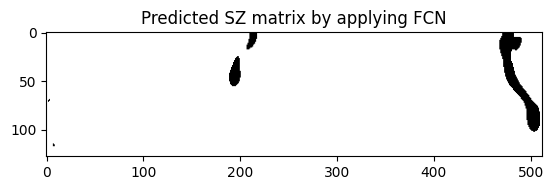

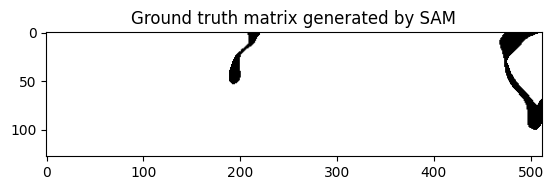

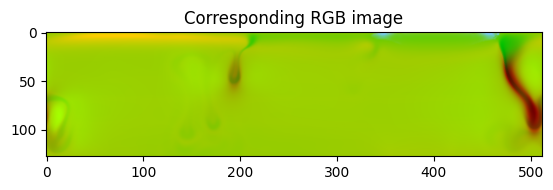

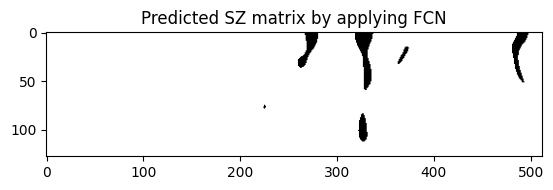

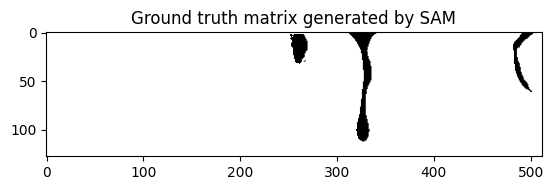

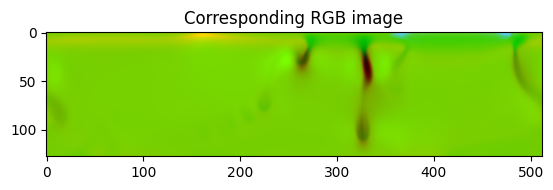

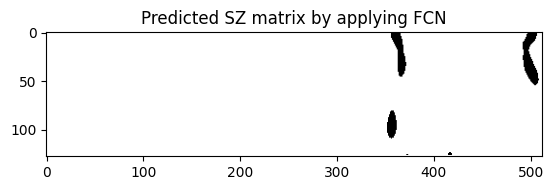

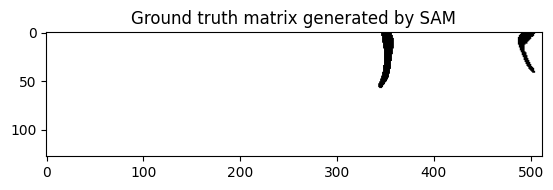

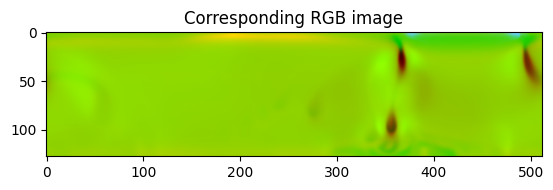

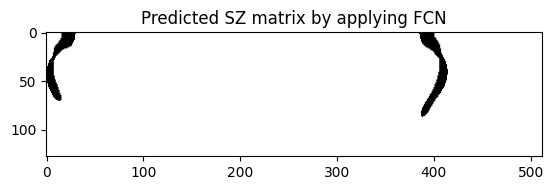

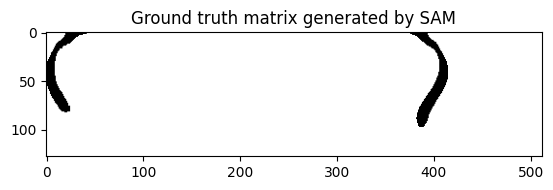

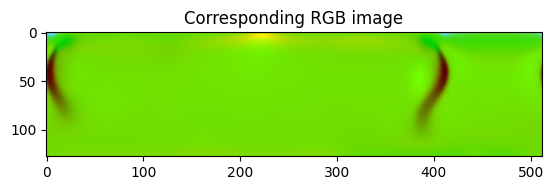

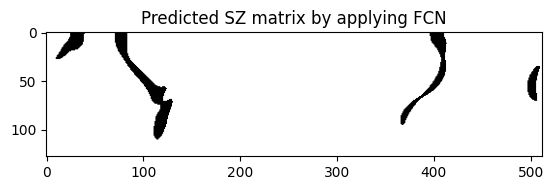

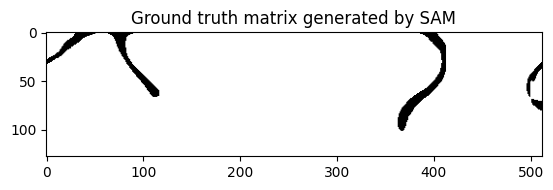

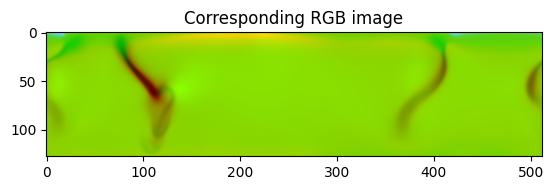

Test avg loss: 0.6138
Test avg Dice: 0.6177


In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = FCN8_ED().to(device)

# Prepare training and evaluation data
X_all, Y_all = [], []
for i in range(51):
    input_temp1 = 'temp' + str(i)
    # input_temp_ha = 'ha_temp' + str(i)
    filename_rgb = f'/content/gdrive/MyDrive/alt_rgb_images/{input_temp1}.pt'
    filename_bool = f'/content/gdrive/MyDrive/boolean_images/boolean_{input_temp1}.o'
    X = torch.load(filename_rgb, weights_only=True).to(device).float()           # [H,W,3]
    Y = torch.load(filename_bool, weights_only=True).to(device).type(torch.FloatTensor)  # [H,W] or [H,W,1]
    # to NCHW
    X = X.unsqueeze(0).permute(0,3,1,2).contiguous()  # [1,3,H,W]
    if Y.ndim == 2:
        Y = Y.unsqueeze(0)  # [1,H,W]
    Y = Y.unsqueeze(0).contiguous()                   # [1,1,H,W]
    X_all.append(X)
    Y_all.append(Y)

# stack to [N, C, H, W] and [N, 1, H, W]
X_all = torch.cat(X_all, dim=0)
Y_all = torch.cat(Y_all, dim=0)

# simple split: last 8 for validation
val_count = max(6, int(0.2 * len(X_all)))  # ~20% or at least 6
X_train, Y_train = X_all[:-val_count], Y_all[:-val_count]
X_val,   Y_val   = X_all[-val_count:],   Y_all[-val_count:]

# --- normalization stats from TRAIN ONLY ---
with torch.no_grad():
    mean = X_train.mean(dim=(0,2,3), keepdim=True)           # shape [1,3,1,1]
    std  = X_train.std (dim=(0,2,3), keepdim=True).clamp_min(1e-6)

def norm(x):   # x: [B,3,H,W]
    return (x - mean) / std

p = compute_positive_prior(Y_train)  # ~0.033
bias_init_final_logits_to_prior(model, p)

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = combined_loss # BCE+Dice
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.2)

# Training
best_model = train_model_with_early_stopping(
    model, criterion, optimizer, scheduler,
    X_train, Y_train, X_val, Y_val, device,
    epochs=100, patience=8, min_delta=1e-3, ckpt_path="best_fcn.pt"
)

torch.save(best_model.state_dict(), "trained_model_fcn_best.pt")

# Evalution loop
# IMPORTANT: load the best checkpoint (from early stopping) before evaluating
model.load_state_dict(torch.load("best_fcn.pt", map_location=device))
model.eval()

test_losses, test_dices = [], []

for i in range(40, 45):
    input_temp1 = f"temp{i}"
    input_temp_ha = f"ha_temp{i}"
    filename_rgb  = f"/content/gdrive/MyDrive/alt_rgb_images/{input_temp1}.pt"
    filename_bool = f"/content/gdrive/MyDrive/boolean_images/boolean_{input_temp1}.o"

    loaded_tensor_rgb  = torch.load(filename_rgb, weights_only=True).to(device).float()   # [H,W,3]
    loaded_tensor_bool = torch.load(filename_bool, weights_only=True).to(device)          # [H,W] or [H,W,1]

    # x -> [1,3,H,W]
    X_eval = loaded_tensor_rgb.permute(2,0,1).unsqueeze(0)  # [1,3,H,W]
    # y can be [H,W], we’ll reshape inside evaluate_one
    y_eval = loaded_tensor_bool.type(torch.FloatTensor)

    loss_i, logits_i, dice_i = evaluate_one(model, criterion, X_eval, y_eval, device)
    test_losses.append(loss_i)
    test_dices.append(dice_i)

    # post-process & plot
    preds_i = (torch.sigmoid(logits_i).squeeze(0).squeeze(0) > 0.5).float()  # [H,W]
    plot_results(preds_i.cpu().numpy(), f"Predicted SZ matrix by applying FCN")
    plot_actual(y_eval.cpu().numpy(), f"Ground truth matrix generated by SAM")
    plot_rgb(loaded_tensor_rgb, f"Corresponding RGB image")

print(f"Test avg loss: {sum(test_losses)/len(test_losses):.4f}")
print(f"Test avg Dice: {sum(test_dices)/len(test_dices):.4f}")